# Compare saved policy-analysis results across runs

Reload the two artifacts that `compare_proofreader_policy.ipynb` saves under each
run's `runs/<run>/policy_analysis/` — the **per-skeleton metric deltas** and the
**split-repair coverage** — for ONE brain, across ALL runs in `runs/`, and replot
them separately.

A run that has not saved these artifacts (for this brain) is **skipped and logged**,
so this notebook never fails on a partial run. No scoring, no cloud — pure reload.

## 0. Parameters & paths

In [1]:
import json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameter: which dataset / brain to compare across runs ---
BRAIN_ID = "789202"

# This notebook lives in proofreader_evolve/, run it from there (same as the other
# notebooks): PROJ -> exa-spim-agent/, RUNS -> proofreader_evolve/runs/.
PROJ = Path("..").resolve()
RUNS = PROJ / "proofreader_evolve" / "runs"
assert RUNS.is_dir(), f"runs dir not found: {RUNS} (run this notebook from proofreader_evolve/)"
print(f"scanning {RUNS} for brain {BRAIN_ID}")

scanning /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs for brain 789202


## 1. Discover saved artifacts across all runs

For each run dir we look in `policy_analysis/` for files matching this brain. A run
with no artifacts is skipped; a run with only one of the two parts is recorded as
*partial*. If multiple generations were saved, we take the newest (highest gen #).

In [2]:
per_skeleton = {}   # run_name -> (gen, DataFrame)   from per_skeleton_deltas_*.csv
coverage = {}       # run_name -> (gen, dict)        from split_repair_coverage_*.json
skipped = []        # (run_name, reason) — no artifacts at all
partial = []        # (run_name, reason) — has one part but not the other

def _gen_of(p):
    m = re.search(r"_(gen\d+)_", p.name)
    return m.group(1) if m else "gen?"

def _newest(paths):
    # sort by the integer gen number so 'gen9' < 'gen30'; fall back to name.
    def _k(p):
        m = re.search(r"_gen(\d+)_", p.name)
        return int(m.group(1)) if m else -1
    return sorted(paths, key=_k)[-1] if paths else None

for run in sorted(p for p in RUNS.iterdir() if p.is_dir()):
    ana = run / "policy_analysis"
    ps = sorted(ana.glob(f"per_skeleton_deltas_*_{BRAIN_ID}.csv")) if ana.is_dir() else []
    cv = sorted(ana.glob(f"split_repair_coverage_*_{BRAIN_ID}.json")) if ana.is_dir() else []
    if not ps and not cv:
        reason = "no policy_analysis/ dir" if not ana.is_dir() else f"no artifacts for brain {BRAIN_ID}"
        skipped.append((run.name, reason)); continue
    if ps:
        p = _newest(ps)
        try:
            per_skeleton[run.name] = (_gen_of(p), pd.read_csv(p, index_col=0))
        except Exception as e:
            partial.append((run.name, f"per-skeleton CSV unreadable ({e})"))
    else:
        partial.append((run.name, "per-skeleton CSV missing (coverage only)"))
    if cv:
        c = _newest(cv)
        try:
            coverage[run.name] = (_gen_of(c), json.loads(c.read_text()))
        except Exception as e:
            partial.append((run.name, f"coverage JSON unreadable ({e})"))
    else:
        partial.append((run.name, "coverage JSON missing (per-skeleton only)"))

print(f"runs with per-skeleton deltas : {len(per_skeleton)}  -> {sorted(per_skeleton)}")
print(f"runs with coverage stats      : {len(coverage)}  -> {sorted(coverage)}")
if partial:
    print(f"\npartial ({len(partial)}):")
    for nm, why in partial: print(f"  - {nm}: {why}")
if skipped:
    print(f"\nskipped ({len(skipped)}) — no saved analysis for brain {BRAIN_ID}:")
    for nm, why in skipped: print(f"  - {nm}: {why}")

runs with per-skeleton deltas : 2  -> ['789202_20260623_213408', '789202_20260623_232105']
runs with coverage stats      : 2  -> ['789202_20260623_213408', '789202_20260623_232105']

skipped (1) — no saved analysis for brain 789202:
  - 789202_20260623_005939: no policy_analysis/ dir


## 2. Per-skeleton metric deltas — one figure per run

Replots, per run, the saved per-skeleton deltas (section 4 of `compare_proofreader_policy.ipynb`) as five panels: **dEdge Accuracy**, **d% Merged Edges**, **d# Splits / base # Splits (%)** (split-count change normalized by the baseline split count, so skeletons of very different size are comparable — a merge repair lowers # Splits, so this is usually negative; it is the relative label-count change, NOT 'split sites fixed'), **d# Merges** (official net change), and **edit-caused merges** (cross-neuron fusions the policy created). Y-ranges are shared across runs per panel. CSVs from an older notebook may lack some columns; those panels show 0 and are flagged `[not in CSV]`.

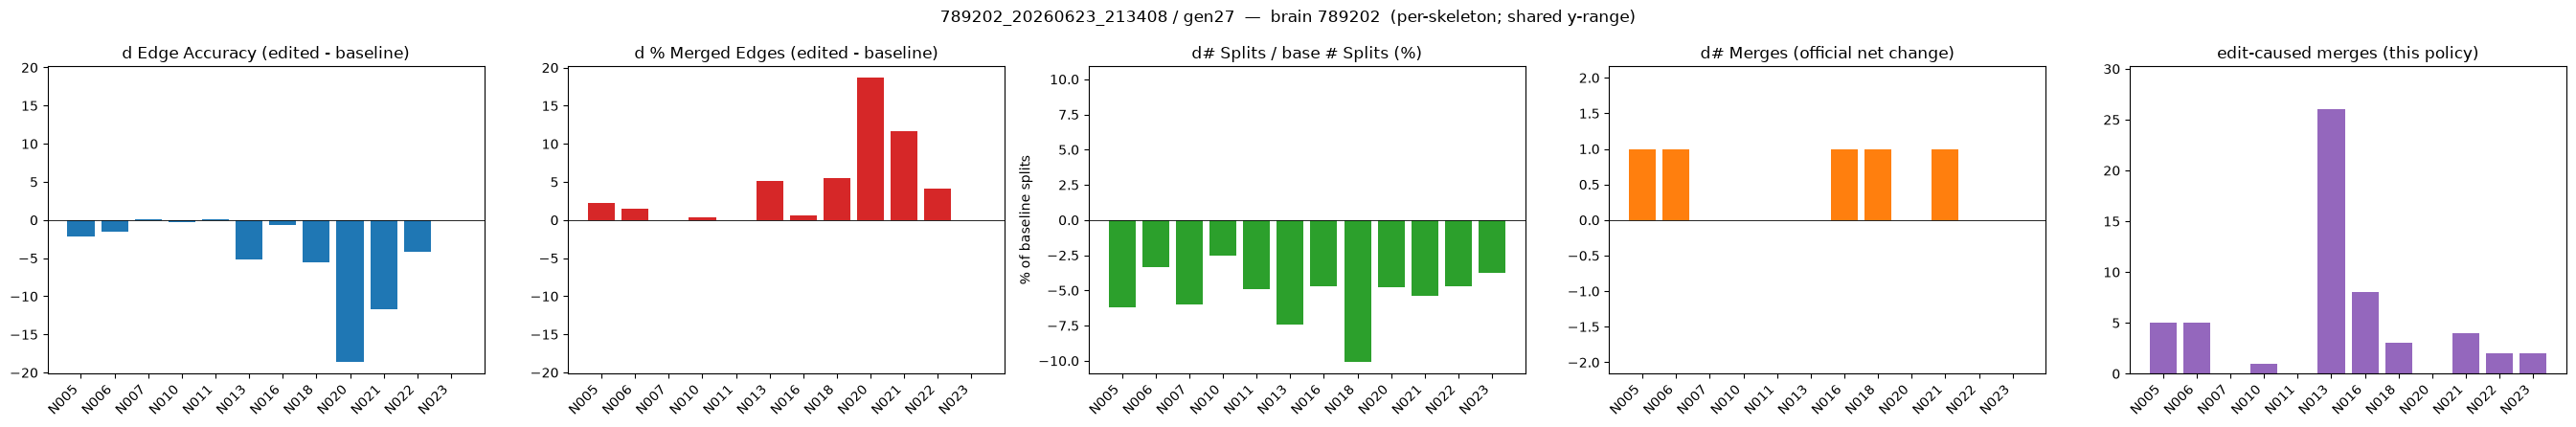

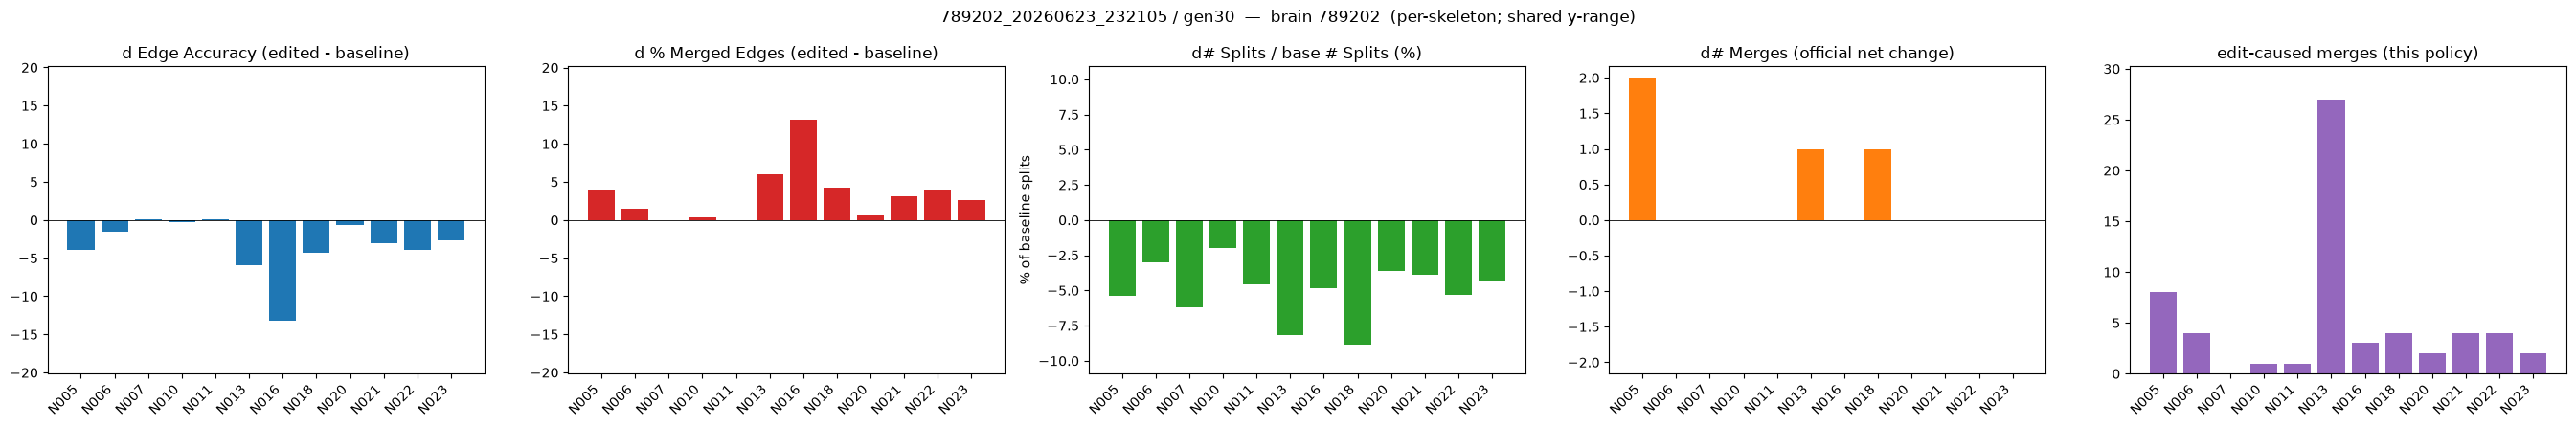

In [3]:
if not per_skeleton:
    print("No per-skeleton deltas saved for any run. Run section 4 of "
          "compare_proofreader_policy.ipynb (it writes the CSV) first.")

# Five per-skeleton panels: dEdgeAcc, d%MergedEdges, d# Splits / base # Splits (%)
# (split-count change normalized by baseline so different-sized skeletons are
# comparable), d# Merges (official net change in merge count), and edit-caused
# merges (cross-neuron fusions the policy created). Note d# Splits is the change in
# the GT skeleton's distinct-label count (a merge repair LOWERS it, so it is
# typically negative) — NOT the same as "how many split sites were fixed" (see the
# coverage section); union-find can drop several labels per repaired place.
# Columns absent from older CSVs fall back to 0 with a "[not in CSV]" title note.
need = ["dEdge Accuracy", "d% Merged Edges"]
_ps_ok = {}
for run_name, (gen, df) in per_skeleton.items():
    per = df.drop(index="WEIGHTED MEAN", errors="ignore")
    if all(c in per.columns for c in need):
        _ps_ok[run_name] = (gen, per)
    else:
        print(f"[skip] {run_name}: missing columns {need} (has {list(per.columns)[:6]}...)")

# Helper to read a column that may be absent in older CSVs -> all-zeros + flag.
def _col_or_zero(per, col):
    if col in per.columns:
        return pd.to_numeric(per[col], errors="coerce").fillna(0.0), True
    return pd.Series(0.0, index=per.index), False

# SHARED y-range across ALL runs, computed per column so bars are comparable
# run-to-run. Signed metrics get a symmetric range about 0; the non-negative count
# (edit-caused merges) gets a 0-based range.
def _shared_range(col, signed):
    vals = []
    for _, per in _ps_ok.values():
        s, _ok = _col_or_zero(per, col)
        vals.append(s.to_numpy())
    vals = np.concatenate(vals) if vals else np.array([0.0])
    if signed:
        m = float(np.nanmax(np.abs(vals))) if vals.size else 1.0
        m = m if m > 0 else 1.0; pad = 0.08 * m
        return (-m - pad, m + pad)
    top = float(np.nanmax(vals)) if vals.size else 1.0
    top = top if top > 0 else 1.0
    return (0, top * 1.12)

_yl_edge   = _shared_range("dEdge Accuracy", signed=True)
_yl_merged = _shared_range("d% Merged Edges", signed=True)
# d# Splits normalized by baseline split count: d# Splits / base # Splits (percent),
# so the split-count change is comparable across skeletons of very different size
# (N005 ~1061 splits vs N020 ~357). base # Splits == 0 -> ratio 0 (no div error).
def _split_ratio(per):
    d, _ = _col_or_zero(per, "d# Splits")
    base, _ = _col_or_zero(per, "base # Splits")
    return (100.0 * d / base.where(base != 0, np.nan)).fillna(0.0)
_ratio_vals = (np.concatenate([_split_ratio(per).to_numpy() for _, per in _ps_ok.values()])
               if _ps_ok else np.array([0.0]))
_rm = float(np.nanmax(np.abs(_ratio_vals))) if _ratio_vals.size else 1.0
_rm = _rm if _rm > 0 else 1.0
_yl_dsplit = (-_rm - 0.08 * _rm, _rm + 0.08 * _rm)
_yl_dmerge = _shared_range("d# Merges", signed=True)
_yl_caused = _shared_range("edit-caused merges", signed=False)

for run_name, (gen, per) in _ps_ok.items():
    names = list(per.index)
    x = np.arange(len(names))
    _xt = [n.split('-')[0] for n in names]
    _ds_raw, _has_ds = _col_or_zero(per, "d# Splits")
    _base_sp, _has_bs = _col_or_zero(per, "base # Splits")
    dsplit_ratio = _split_ratio(per)            # d# Splits / base # Splits, percent
    dmerge, _has_dm = _col_or_zero(per, "d# Merges")
    caused, _has_cz = _col_or_zero(per, "edit-caused merges")
    fig, axes = plt.subplots(1, 5, figsize=(27, 4.5))
    axes[0].bar(x, per["dEdge Accuracy"], color="#1f77b4")
    axes[0].axhline(0, color="k", lw=0.6); axes[0].set_title("d Edge Accuracy (edited - baseline)")
    axes[0].set_ylim(*_yl_edge)
    axes[0].set_xticks(x); axes[0].set_xticklabels(_xt, rotation=45, ha="right")
    axes[1].bar(x, per["d% Merged Edges"], color="#d62728")
    axes[1].axhline(0, color="k", lw=0.6); axes[1].set_title("d % Merged Edges (edited - baseline)")
    axes[1].set_ylim(*_yl_merged)
    axes[1].set_xticks(x); axes[1].set_xticklabels(_xt, rotation=45, ha="right")
    axes[2].bar(x, dsplit_ratio, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.6)
    _ds_note = "" if (_has_ds and _has_bs) else " [not in CSV]"
    axes[2].set_title("d# Splits / base # Splits (%)" + _ds_note)
    axes[2].set_ylabel("% of baseline splits")
    axes[2].set_ylim(*_yl_dsplit)
    axes[2].set_xticks(x); axes[2].set_xticklabels(_xt, rotation=45, ha="right")
    axes[3].bar(x, dmerge, color="#ff7f0e")
    axes[3].axhline(0, color="k", lw=0.6)
    axes[3].set_title("d# Merges (official net change)" + ("" if _has_dm else " [not in CSV]"))
    axes[3].set_ylim(*_yl_dmerge)
    axes[3].set_xticks(x); axes[3].set_xticklabels(_xt, rotation=45, ha="right")
    axes[4].bar(x, caused, color="#9467bd")
    axes[4].set_title("edit-caused merges (this policy)" + ("" if _has_cz else " [not in CSV]"))
    axes[4].set_ylim(*_yl_caused)
    axes[4].set_xticks(x); axes[4].set_xticklabels(_xt, rotation=45, ha="right")
    fig.suptitle(f"{run_name} / {gen}  —  brain {BRAIN_ID}  (per-skeleton; shared y-range)")
    fig.tight_layout(); plt.show()

## 3. Split-repair coverage — one figure per run + cross-run summary

Per run: per-site **fixed vs remaining** (train & held-out), annotated with coverage%. The `image_reader_enabled` flag is shown in each title — a `GEOMETRY-ONLY` run was saved with the image reader OFF, so its numbers are a subset, not the policy's true score. A cross-run summary table + held-out per-edit comparison closes the section.

> **Coverage% here is NOT the `d# Splits / base # Splits (%)` panel in section 2 — different denominators, different meaning:**
>
> - **Coverage% (this section, ~40%)** = *fixed* ÷ ***reachable real splits***. A "reachable real split" is an enumerated **SplitSite** (a GT-free geometric candidate: two differently-labelled fragment tips that sit close) that survives two GT filters — its two labels' **dominant GT neuron is the SAME** (so merging them truly repairs one broken neuron, not a FALSE join of two neurons) **and** that neuron is GT-covered. So the denominator is the *candidate* pool the policy could act on (e.g. 5000 SplitSites → ~1151 reachable real splits), and coverage answers *“of the real splits I can reach, what fraction did I close?”*
>
> - **`d# Splits / base # Splits (%)` (section 2, ~5–10%)** = the net change in a GT skeleton's **distinct-label count** ÷ that skeleton's **entire** baseline split count (often thousands). It is a relative *label-count* change over ALL splits on the neuron, shrunk further because union-find chaining and omit-healing partly cancel in the net — **not** a repair rate.
>
> Same word "split", but one is *fixed / reachable-candidate* (a coverage rate) and the other is *net label-count Δ / all-baseline-splits* (a relative count change), so the two percentages are not comparable.

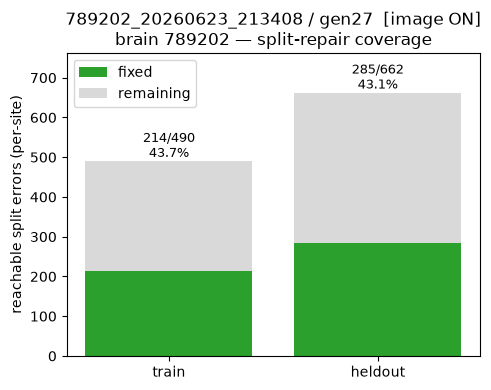

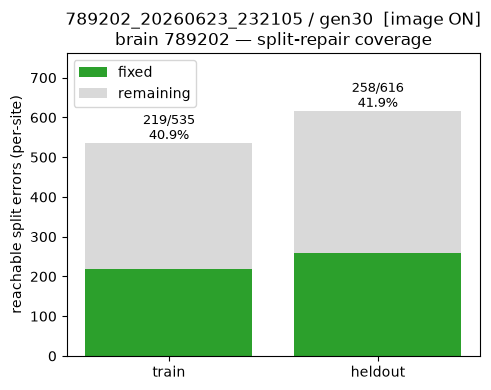

=== cross-run summary (brain 789202) ===


,gen,image,n_edits,train_fixed,train_remaining,train_correct(edit),train_false(edit),heldout_fixed,heldout_remaining,heldout_correct(edit),heldout_false(edit)
run,,,,,,,,,,,
789202_20260623_213408,gen27,True,2296,214,276,222,0,285,377,293,0
789202_20260623_232105,gen30,True,2153,219,316,219,0,258,358,259,0


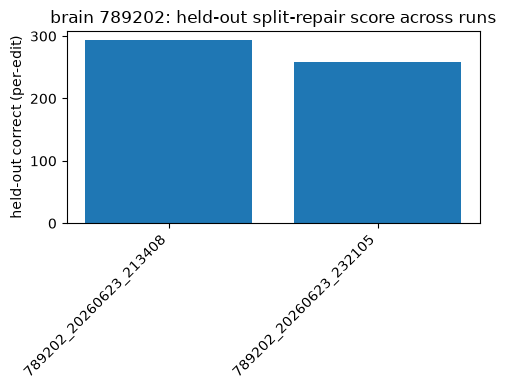

In [4]:
if not coverage:
    print("No coverage stats saved for any run. Run section 8 of "
          "compare_proofreader_policy.ipynb (it writes the JSON) first.")

buckets = ["train", "heldout"]

# SHARED y-max across ALL runs: the tallest stacked bar (fixed + remaining) over
# every run and bucket, so coverage bars are directly comparable run-to-run.
_tot_max = 0
for _, (_, cov) in coverage.items():
    ps_ = cov.get("per_site", {})
    for b in buckets:
        _tot_max = max(_tot_max, ps_.get(b, {}).get("fixed", 0) + ps_.get(b, {}).get("remaining", 0))
_y_top = (_tot_max * 1.15) if _tot_max else 1.0   # headroom for the count/pct labels

summary_rows = []
for run_name, (gen, cov) in coverage.items():
    ps_ = cov.get("per_site", {})
    pe_ = cov.get("per_edit", {})
    img = cov.get("image_reader_enabled", None)
    tag = "" if img is None else ("  [image ON]" if img else "  [GEOMETRY-ONLY]")
    fixed = [ps_.get(b, {}).get("fixed", 0) for b in buckets]
    remaining = [ps_.get(b, {}).get("remaining", 0) for b in buckets]
    x = np.arange(len(buckets))
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(x, fixed, label="fixed", color="#2ca02c")
    ax.bar(x, remaining, bottom=fixed, label="remaining", color="#d9d9d9")
    ax.set_ylim(0, _y_top)   # shared across runs
    for i in range(len(buckets)):
        tot = fixed[i] + remaining[i]
        pct = (100.0 * fixed[i] / tot) if tot else 0.0
        ax.text(i, tot, f"{fixed[i]}/{tot}\n{pct:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(buckets)
    ax.set_ylabel("reachable split errors (per-site)")
    ax.set_title(f"{run_name} / {gen}{tag}\nbrain {BRAIN_ID} — split-repair coverage")
    ax.legend()
    fig.tight_layout(); plt.show()
    row = {"run": run_name, "gen": gen, "image": img,
           "n_edits": cov.get("n_merge_labels_edits")}
    for b in buckets:
        row[f"{b}_fixed"] = ps_.get(b, {}).get("fixed", 0)
        row[f"{b}_remaining"] = ps_.get(b, {}).get("remaining", 0)
        row[f"{b}_correct(edit)"] = pe_.get(b, {}).get("correct", 0)
        row[f"{b}_false(edit)"] = pe_.get(b, {}).get("false", 0)
    summary_rows.append(row)

if summary_rows:
    summ = pd.DataFrame(summary_rows).set_index("run").sort_index()
    print("=== cross-run summary (brain %s) ===" % BRAIN_ID)
    try:
        display(summ)
    except NameError:
        print(summ.to_string())
    # Headline cross-run comparison: held-out per-edit correct (the gate's score).
    fig, ax = plt.subplots(figsize=(max(5, 0.9 * len(summ)), 4))
    ax.bar(range(len(summ)), summ["heldout_correct(edit)"], color="#1f77b4")
    ax.set_xticks(range(len(summ)))
    ax.set_xticklabels(summ.index, rotation=45, ha="right")
    ax.set_ylabel("held-out correct (per-edit)")
    ax.set_title(f"brain {BRAIN_ID}: held-out split-repair score across runs")
    fig.tight_layout(); plt.show()